# 📧 Example 3: Spam Email Classifier (Logistic Regression + TF-IDF)

This notebook constructs and evaluates a **spam detection** pipeline using **TF-IDF vectorization** for text features and **Logistic Regression** for classification. Messages are labeled as **Spam (0)** or **Ham (1)**.

In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1) Load and Inspect the Dataset

The dataset contains text messages labeled as either **Spam** or **Ham** (legitimate).  
Each record includes two main columns:

- **Category:** The label indicating whether the message is spam or not.  
- **Message:** The actual text content of the email or SMS message.  

In [ ]:
# Load dataset (ensure the CSV is available in the working directory)
df = pd.read_csv("Example_3_Spam_Email_Classifier.csv")

# Basic structural check
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5572, 2)


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2) Clean and Encode Labels

Before training, the dataset must be cleaned and standardized to ensure consistency.  

1. **Handle missing values:**  
   Any missing message text is replaced with an empty string (`""`) to avoid errors during text vectorization.

2. **Normalize labels:**  
   All category labels are converted to lowercase (`spam`, `ham`) to maintain uniformity.

3. **Encode labels numerically:**  
   Machine learning models require numeric input, so the labels are converted as follows:  
   - `spam → 0` (unwanted or junk message)  
   - `ham → 1` (legitimate, non-spam message)


In [ ]:
# ---------------------------------------------------------------------
# Handle missing values
# ---------------------------------------------------------------------
# Replace any missing text entries (NaN) in the dataset with empty strings.
# This prevents errors during text processing and ensures all rows are valid.
df = df.fillna("")

# ---------------------------------------------------------------------
# Normalize and encode labels
# ---------------------------------------------------------------------
# Convert all category labels to lowercase for consistency.
df["Category"] = df["Category"].str.lower()

# Map text labels to numeric values for model training:
#   spam → 0 (unwanted message)
#   ham  → 1 (legitimate message)
df["Label"] = df["Category"].map({"spam": 0, "ham": 1})

df.head()

,Category,Message,Label
0,ham,"Go until jurong point, crazy.. Available only ...",1
1,ham,Ok lar... Joking wif u oni...,1
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,0
3,ham,U dun say so early hor... U c already then say...,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",1


## 3) Split into Training and Test Sets

The dataset is divided into two subsets to evaluate how well the model generalizes to unseen messages:  
- **80%** of the data is used for training the model.  
- **20%** is reserved for testing and evaluation.  

The parameter `stratify=y` ensures that both subsets maintain the same proportion of **spam** and **ham** messages as in the original dataset.  
This helps prevent class imbalance in the test set and provides a more reliable measure of model performance.

In [ ]:
# ---------------------------------------------------------------------
# Define features and target labels
# ---------------------------------------------------------------------
# X contains the email or SMS text messages (input features).
# y contains the numeric labels where:
#       0 = Spam (unwanted message)
#       1 = Ham (legitimate message)
X = df["Message"].astype(str)
y = df["Label"].astype(int)

# ---------------------------------------------------------------------
# Split the dataset into training and testing subsets
# ---------------------------------------------------------------------
# train_test_split divides the data into two parts:
#       - Training set (80%) for model learning
#       - Test set (20%) for evaluating model performance

# Parameters:
#       test_size=0.20 → 20% of data used for testing
#       stratify=y     → preserves the same spam-to-ham ratio in both sets
#       random_state=3 → ensures reproducible splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=3
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (4457,)
Test size : (1115,)


## 4) Convert Text into TF-IDF Features

Machine learning models cannot process raw text directly, so the messages are converted into numerical feature vectors using **TF-IDF (Term Frequency–Inverse Document Frequency)**.  
  
- This method helps the model understand which words are important in a message and which words are common and less useful.

### How it works:

1. **Term Frequency (TF):**  
   This measures how often a word appears in a single message.  
   For example, in the message “win a free prize”, the word *free* appears once, so its TF value is 1.

2. **Inverse Document Frequency (IDF):**  
   This measures how rare a word is across all messages in the dataset.  
   - Words that appear in almost every message, like “the” or “you”, get a low IDF score because they do not help identify spam.  
   - Rare words such as “lottery” or “offer” get a high IDF score because they are more meaningful for classification.

3. **TF-IDF Score:**  
   The final value is the product of TF and IDF.  
   $$
   \text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)
   $$
   Words that appear often in one message but rarely in others receive a higher score, while very common words get lower scores.

### Why TF-IDF is useful

- It helps the model focus on words that carry meaning, such as “free”, “win”, or “cash”.  
- It reduces the effect of common words that appear in both spam and normal messages.  
- It creates a numeric representation of each message that can be used by algorithms like Logistic Regression.

In [ ]:
# ---------------------------------------------------------------------
# Initialize the TF-IDF vectorizer
# ---------------------------------------------------------------------
# The TfidfVectorizer converts raw text messages into numerical feature vectors.
# Parameters:
#   ngram_range=(1,2)     ->  includes both single words (unigrams) and two-word phrases (bigrams). This helps the model capture short expressions like “free prize” or “click now”
#   stop_words="english"  ->  removes common English words such as "the", "and", "is" since these words appear in almost every message and add little meaning
#   lowercase=True        ->  converts all text to lowercase to ensure that words like "Free" and "free" are treated the same
tfidf = TfidfVectorizer(ngram_range=(1,2), stop_words="english", lowercase=True)

# ---------------------------------------------------------------------
# Fit the vectorizer on the training data and transform it into TF-IDF features
# ---------------------------------------------------------------------
# fit_transform() does two things:
#   1. Learns the vocabulary and IDF (inverse document frequency) values from the training data
#   2. Converts each message into a numerical TF-IDF feature vector
# The result is a matrix where:
#   - Each row represents one message
#   - Each column represents a word or phrase (feature)
X_train_tfidf = tfidf.fit_transform(X_train)

# ---------------------------------------------------------------------
# Apply the same transformation to the test data
# ---------------------------------------------------------------------
# Only transform the test set (do not fit again) to prevent data leakage.
# This ensures that the test data is represented using the same vocabulary and scaling learned from the training data.
X_test_tfidf = tfidf.transform(X_test)

# ---------------------------------------------------------------------
# Display the shape of the resulting TF-IDF feature matrix
# ---------------------------------------------------------------------
# The output shows (number_of_messages, number_of_features).
# For example, (4457, 10000) would mean 4457 training messages and 10,000 distinct word or phrase features.
print("TF-IDF feature shape (train):", X_train_tfidf.shape)


TF-IDF feature shape (train): (4457, 31435)


## 5) Train the Logistic Regression Model

Logistic Regression is a commonly used algorithm for **text classification** tasks such as spam detection.  
It works well with **TF-IDF features**, which are often large and sparse (mostly zeros).

### Why Logistic Regression is used
- It builds a **linear decision boundary** that separates spam and non-spam messages.  
- It is **fast to train** and performs well even with thousands of features.  
- It supports **regularization**, which prevents the model from overfitting to the training data.  

### Key parameter
- `max_iter=1000` allows more optimization steps so that the model can fully converge, especially when dealing with large text datasets.

In [ ]:
# Create and train the classifier (increase max_iter to ensure convergence)
model = LogisticRegression(C=2.0, max_iter=1000)
model.fit(X_train_tfidf, y_train)
print("Model training complete.")

Model training complete.


## 6) Evaluate Model Performance

After training, the model’s performance is measured to understand how accurately it predicts spam and non-spam messages.

### Key evaluation metrics

1. **Accuracy:**  
   The percentage of total predictions that the model got correct.  
   It is calculated for both the training and test sets to check if the model is generalizing well.

2. **Confusion Matrix:**  
   A table that compares actual and predicted labels.  
   It shows:
   - True Positives (correctly predicted spam)  
   - True Negatives (correctly predicted ham)  
   - False Positives (ham predicted as spam)  
   - False Negatives (spam predicted as ham)  
   This helps identify the types of mistakes the model is making.

3. **Classification Report:**  
   Provides detailed metrics for each class:
   - **Precision:** Out of all messages predicted as spam, how many were actually spam.  
   - **Recall:** Out of all real spam messages, how many the model correctly identified.  
   - **F1-Score:** A balanced measure that combines both precision and recall.


Training accuracy: 0.977
Testing  accuracy: 0.978


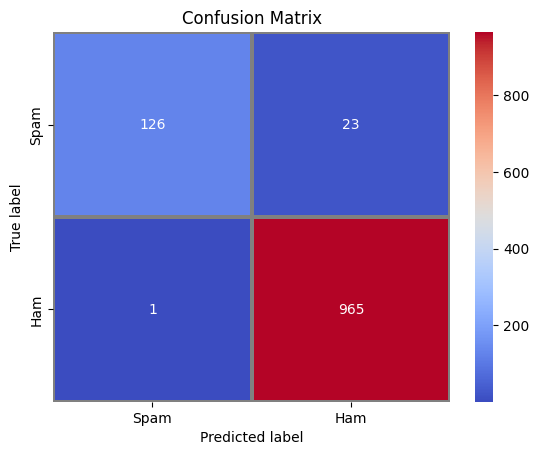


Classification Report:

              precision    recall  f1-score   support

        Spam       0.99      0.85      0.91       149
         Ham       0.98      1.00      0.99       966

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [ ]:
# Predictions on training and test sets
train_pred = model.predict(X_train_tfidf)
test_pred  = model.predict(X_test_tfidf)

# Accuracy
print(f"Training accuracy: {accuracy_score(y_train, train_pred):.3f}")
print(f"Testing  accuracy: {accuracy_score(y_test,  test_pred):.3f}")

# Confusion matrix
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            cbar=True, linewidths=1.5, linecolor='gray',
            xticklabels=['Spam', 'Ham'],
            yticklabels=['Spam', 'Ham'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, test_pred, target_names=['Spam','Ham']))

## 7) Predict New Messages

Once the model has been trained, it can classify new or unseen messages as **Spam** or **Ham**.  

Before making predictions, the incoming text is first transformed using the **same TF-IDF vectorizer** that was fitted on the training data.  
- This ensures that the new message is represented in the same feature space as the data used to train the model.  

The processed text is then passed to the trained **Logistic Regression** model, which outputs a prediction.

In [ ]:
# ---------------------------------------------------------------------
# FUNCTION: Classify a new email or message
# ---------------------------------------------------------------------
def classify_email(text: str) -> str:
    """
    Classifies an input email or message as Spam or Ham using the trained TF-IDF and Logistic Regression pipeline.

    Parameters:
        text (str): The raw text message to be classified.

    Returns:
        str: A human-readable label —
             "Ham (not spam)" if the message is legitimate,
             "Spam" if it is unwanted or promotional.
    """

    # Convert the raw text into a TF-IDF vector using the fitted vectorizer
    # This transforms the message into the same numerical format used for training
    features = tfidf.transform([text])

    # Use the trained Logistic Regression model to predict the class (0 or 1)
    # 0 = Spam, 1 = Ham
    pred = model.predict(features)[0]

    # Return a clear label based on the model's prediction
    return "Ham (not spam)" if pred == 1 else "Spam"


# ---------------------------------------------------------------------
# EXAMPLE PREDICTIONS
# ---------------------------------------------------------------------
print(classify_email("Please review the attached document."))
print(classify_email("You won a FREE iPhone! Click now!"))

Ham (not spam)
Spam
